# **Project Overview**
This notebook focuses on developing and assessing machine learning models aimed at predicting credit card payment defaults. The analysis uses a dataset made up of 34,788 records and 30 features. These features include demographic details, credit limits, billing statements, and payment histories from April to September 2005.

The main goal is to predict the target variable, default.payment.next.month. A value of 1 indicates a default, while 0 means no default.

# **Task 1**
This first section covers the environment setup by importing key Python libraries and loading the source data into a Pandas DataFrame.

Key Libraries Used:
NumPy and Pandas: Used for efficient numerical computation and data manipulation.
Matplotlib and Seaborn: Used for creating data visualizations.
Scikit-learn (sklearn): Provides the machine learning algorithms and metrics needed for model evaluation.
Warnings: Suppressed to keep the output clear and readable.

The dataset is loaded using a semicolon delimiter to match the CSV file format. After loading, the DataFrame dimensions are displayed to confirm successful data retrieval.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load Dataset
df = pd.read_csv("/content/Credit_Card.csv", sep=";", low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (34788, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


# **Task 2**
Understanding the dataset through Exploratory Data Analysis (EDA) is an essential step before building a model. It helps reveal the underlying structure, distributions, and relationships between features before any data changes.

**Analysis of Target Variable Distribution**  
The initial phase involves checking the class balance of default.payment.next.month. Credit risk data often shows class imbalance, where non-defaulters greatly outnumber defaulters. This imbalance can cause models to favor the larger class while giving misleading accuracy. Therefore, relying only on accuracy is not enough for evaluation.

**Summary Statistics and Key Metrics**  
Key numerical features, such as LIMIT_BAL, AGE, BILL_AMT_SUM, LIMIT_BAL_LOG, and risk_leak, are assessed using descriptive statistics like mean, median, and standard deviation. These metrics help clarify the central tendency, scale, and spread of the data.

**Missing Values and Duplicates**  
It is essential to tackle integrity issues before training the model. The dataset has missing entries in fields like LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE, and several PAY_AMT columns. Additionally, removing the 4,788 duplicate rows is necessary to prevent metric inflation and ensure the model does not learn from repeated information.

**Data Visualization Techniques**  
Visual tools offer deeper insights: histograms show skewness and distribution shapes, while box plots help identify outliers. Bar charts are also used to observe the frequency of categories within variables like SEX, EDUCATION, MARRIAGE, and RISK_RATING.

**Investigating Feature Correlations  **
A correlation heatmap reveals which features have the strongest linear connections to the target variable. Features such as RISK_RATING and PAY_0, which track recent repayment status, are expected to show strong correlations with default outcomes.

Target variable distribution:
default.payment.next.month
0    28132
1     6656
Name: count, dtype: int64

Class balance (%):
default.payment.next.month
0    80.866966
1    19.133034
Name: proportion, dtype: float64


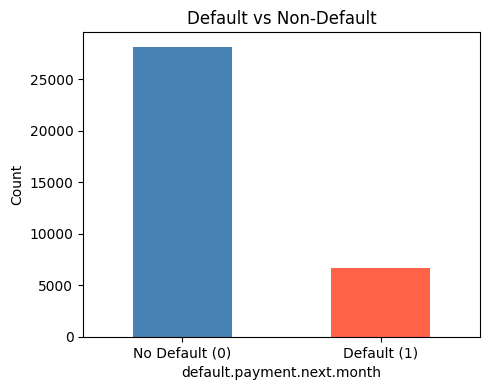


Descriptive Statistics:


,LIMIT_BAL,AGE,BILL_AMT_SUM
count,3.307900e+04,33033.000000,3.478800e+04
mean,1.846690e+05,35.518300,2.948152e+05
std,2.359319e+05,9.236783,5.718073e+05
min,1.000000e+04,21.000000,-3.362590e+05
25%,6.000000e+04,28.000000,2.973825e+04
50%,1.400000e+05,34.000000,1.290370e+05
75%,2.400000e+05,41.000000,3.502095e+05
max,5.600000e+06,79.000000,2.129266e+07


In [2]:
print("Target variable distribution:")
print(df["default.payment.next.month"].value_counts())
print("\nClass balance (%):")
print(df["default.payment.next.month"].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
df["default.payment.next.month"].value_counts().plot(kind="bar", color=["steelblue","tomato"])
plt.title("Default vs Non-Default")
plt.xticks([0,1], ["No Default (0)", "Default (1)"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("\nDescriptive Statistics:")
df[["LIMIT_BAL","AGE","BILL_AMT_SUM","LIMIT_BAL_LOG","risk_leak"]].describe()

Missing values per column:
LIMIT_BAL        1709
SEX              1767
EDUCATION        1734
MARRIAGE         1733
AGE              1755
PAY_AMT1         1725
PAY_AMT2         1744
LIMIT_BAL_LOG    1709
dtype: int64

Duplicate rows: 4788


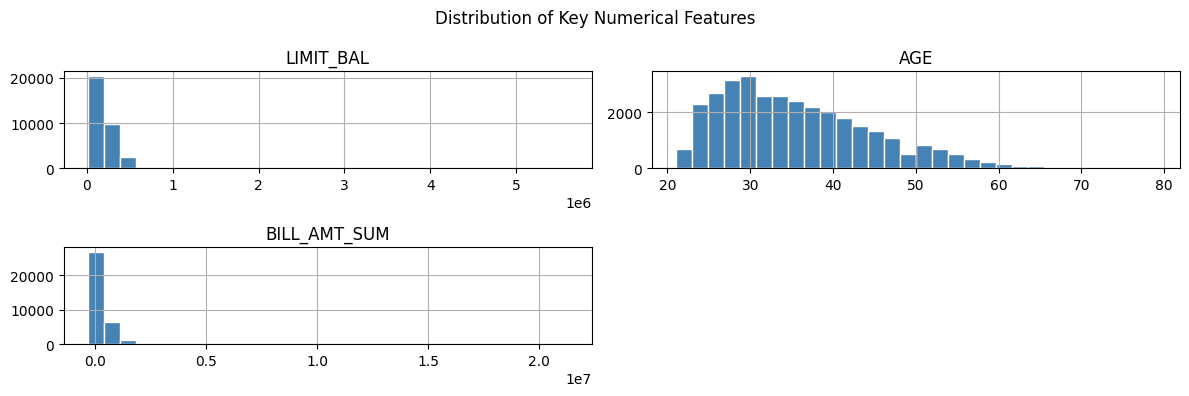

In [3]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\nDuplicate rows: {df.duplicated().sum()}")

num_cols = ["LIMIT_BAL", "AGE", "BILL_AMT_SUM"]
df[num_cols].hist(bins=30, figsize=(12,4), color="steelblue", edgecolor="white")
plt.suptitle("Distribution of Key Numerical Features")
plt.tight_layout()
plt.show()

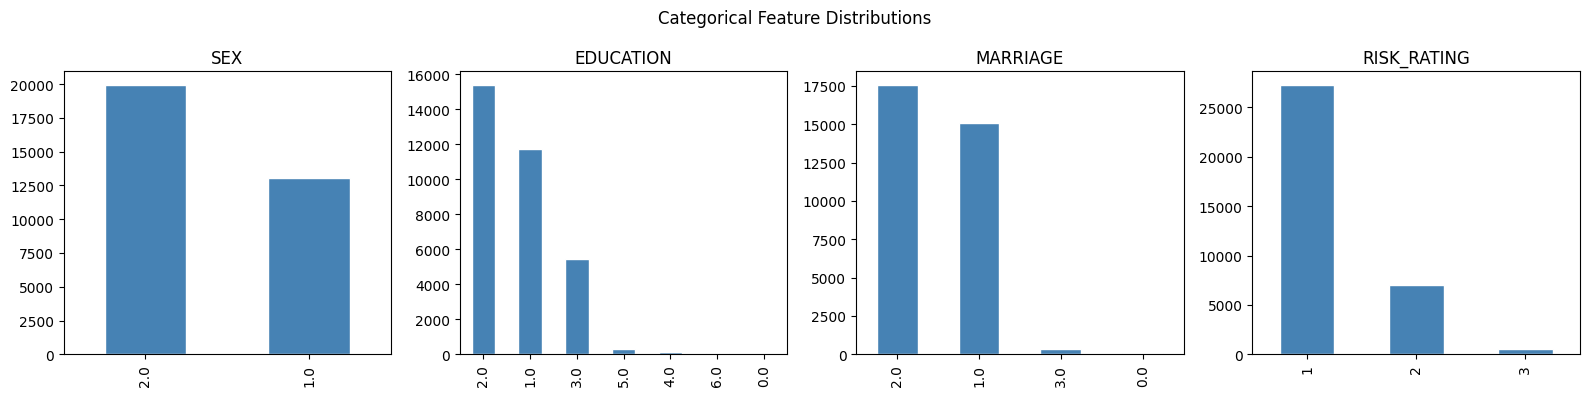

In [4]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE", "RISK_RATING"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Categorical Feature Distributions")
plt.tight_layout()
plt.show()

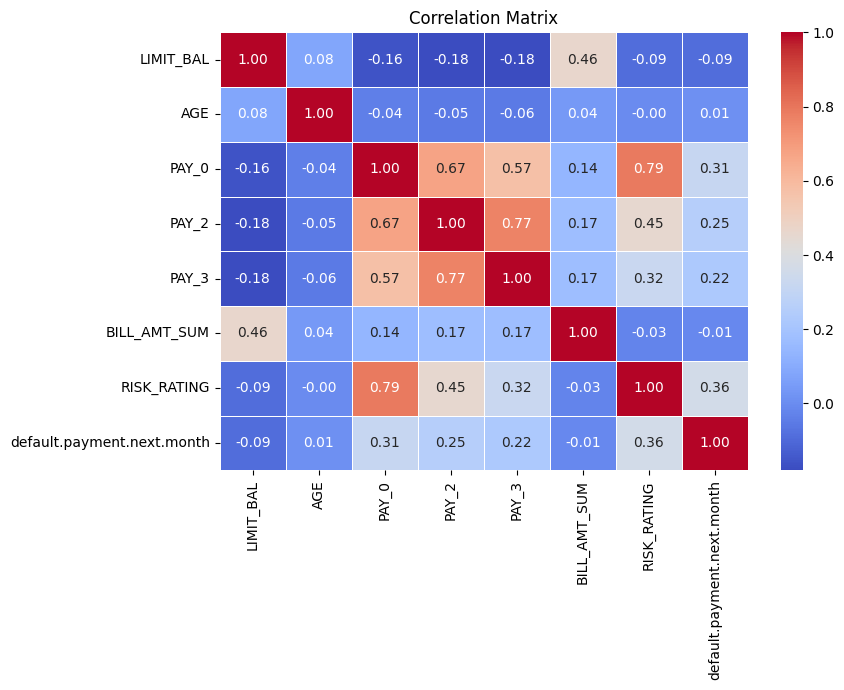

In [5]:
corr_cols = ["LIMIT_BAL","AGE","PAY_0","PAY_2","PAY_3",
             "BILL_AMT_SUM","RISK_RATING","default.payment.next.month"]
plt.figure(figsize=(9,7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

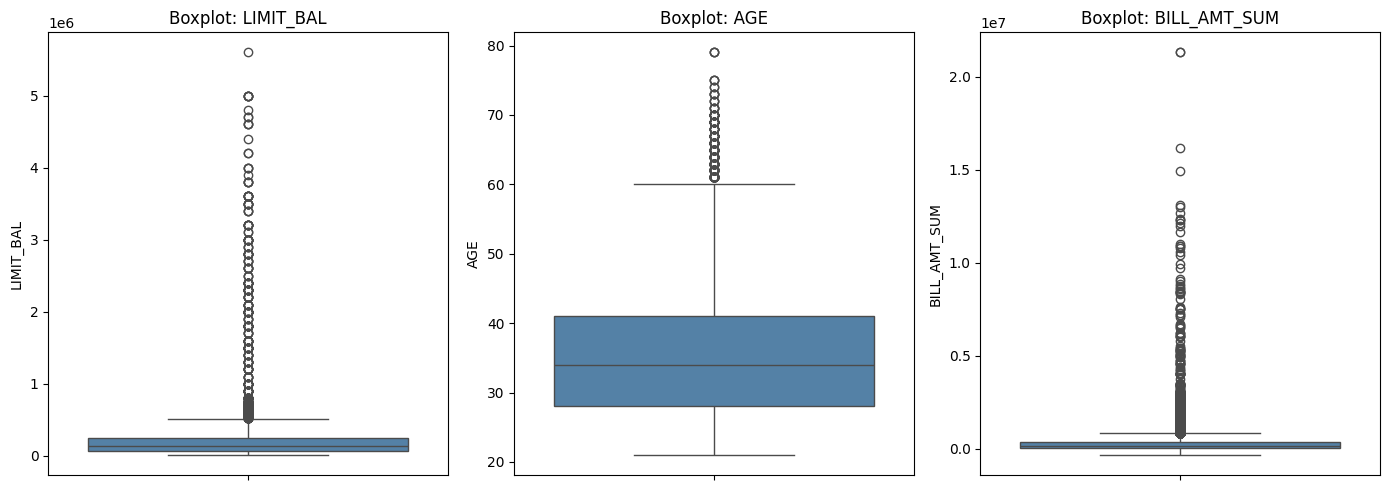

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14,5))
for ax, col in zip(axes, ["LIMIT_BAL","AGE","BILL_AMT_SUM"]):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

# **Task 3**

Raw data is almost never ready for machine learning straight away. This section deals with missing values, removes unnecessary features, manages duplicates, encodes categorical variables, and scales numerical features.

**Dropping Irrelevant and Leakage Columns**

Three columns are removed before any further processing:

- ID: This is a unique row identifier that has no predictive value. Adding it would not help the model to learn any patterns.

- risk_leak: This column reflects a continuous risk score based on payment behavior. Since payment behavior directly relates to the target variable (default), including risk_leak would lead to data leakage. The model would gain access to information it wouldn’t have in a real-world scenario. This would result in inflated performance metrics that would not apply to new data.

- LIMIT_BAL_LOG: This is simply the natural logarithm of LIMIT_BAL, which is already in the dataset. Including both would create redundancy, as they provide the same underlying information in different forms.

**Removing Duplicate Rows**

4,788 duplicate rows are removed using drop_duplicates(). Keeping duplicates is a problem because the same records might show up in both the training and test sets after splitting. This could cause the model to memorize instead of learn, leading to overly optimistic evaluation scores.

**Handling Missing Values**

Missing values in numerical columns are filled using the median of each column. The median is favored over the mean because it is less affected by outliers. Extreme values in financial data, like very high credit limits, can significantly distort the mean.

Missing values in categorical columns (object type) are filled with the mode, or the most frequently occurring value in those columns.

**Encoding Categorical Variables**

The CITY column has 50 unique string labels (City_1 to City_50). Since machine learning algorithms need numerical input, One-Hot Encoding is applied using pd.get_dummies(). This creates a binary column for each city. The option drop_first=True is used to prevent the dummy variable trap, where one category can be perfectly predicted from the others.

**Outlier Handling**

Extreme values in LIMIT_BAL, AGE, and BILL_AMT_SUM are capped at the 5th and 95th percentiles. This reduces the impact of extreme outliers without removing those rows completely from the dataset, keeping the sample size intact.

In [7]:
data = df.copy()

data.drop(columns=["ID", "risk_leak", "LIMIT_BAL_LOG"], inplace=True)

before = len(data)
data.drop_duplicates(inplace=True)
print(f"Removed {before - len(data)} duplicate rows. Remaining: {len(data)}")

num_cols = data.select_dtypes(include=["float64","int64"]).columns.tolist()
num_cols = [c for c in num_cols if c != "default.payment.next.month"]
for col in num_cols:
    median_val = data[col].median()
    data[col].fillna(median_val, inplace=True)

cat_cols = data.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

print("Missing values after imputation:", data.isnull().sum().sum())

data = pd.get_dummies(data, columns=["CITY"], drop_first=True)
print("Shape after encoding:", data.shape)

for col in ["LIMIT_BAL", "AGE", "BILL_AMT_SUM"]:
    upper = data[col].quantile(0.95)
    lower = data[col].quantile(0.05)
    data[col] = data[col].clip(lower, upper)

print("Data preparation complete.")
print(data.shape)

Removed 4788 duplicate rows. Remaining: 30000
Missing values after imputation: 0
Shape after encoding: (30000, 75)
Data preparation complete.
(30000, 75)


# **Task 4**

**Train/Test Split**

The dataset is divided into 80% for training and 20% for testing using train_test_split(). The 80/20 ratio is a common standard. It provides enough data for the model to learn patterns while keeping a significant portion unseen for evaluation.

The stratify=y parameter ensures that the balance between defaulters and non-defaulters is maintained in both the training and test sets. Without stratification, one set could accidentally have too many instances of one class.

**Feature Scaling**

StandardScaler is used to transform all numerical features so they have a mean of 0 and a standard deviation of 1. This is important for distance-based algorithms like K-Nearest Neighbors and SVM. Without this scaling, features with larger numerical values would dominate the distance calculations.

The scaler is fitted only on the training set using fit_transform(), and then it is applied (not refitted) to the test set using transform(). Fitting the scaler on the entire dataset before splitting would cause data leakage, as the statistical distribution of the test set would affect the scaling of the training data.

**Model Selection and Justification**

Six classification algorithms are trained:

- Logistic Regression: A simple baseline model. It is easy to interpret and computationally efficient. class_weight='balanced' is used to address class imbalance.

- Support Vector Machine (SVM): This algorithm works well in high-dimensional spaces. CalibratedClassifierCV is used with LinearSVC to provide probability outputs needed for generating the ROC curve.

- Decision Tree: A non-linear model that creates interpretable if-then rules. max_depth=10 helps to prevent overfitting on the training data.

- Random Forest: This method combines multiple decision trees and reduces overfitting by averaging predictions from 100 trees. It is generally robust to class imbalance, using class_weight='balanced'.

- K-Nearest Neighbors (KNN): This algorithm classifies based on the majority class of the k=5 nearest data points. It is sensitive to feature scale, making scaling essential.

- Gradient Boosting: This approach builds trees one after another, with each new tree correcting mistakes from the previous one. It usually performs well on tabular data.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

RANDOM_STATE = 42

X = data.drop("default.payment.next.month", axis=1)
y = data["default.payment.next.month"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set:     {X_test_scaled.shape}")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3) * 100)

Training set: (24000, 74)
Test set:     (6000, 74)

Class balance in training set:
default.payment.next.month
0    77.9
1    22.1
Name: proportion, dtype: float64


In [9]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),

    "SVM": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", max_depth=10, random_state=RANDOM_STATE),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=100, random_state=RANDOM_STATE),

    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted")
    print(f"{name:<25} Accuracy: {acc:.4f}  F1: {f1:.4f}")

Logistic Regression       Accuracy: 0.7667  F1: 0.7722
SVM                       Accuracy: 0.7975  F1: 0.7674
Decision Tree             Accuracy: 0.7080  F1: 0.7268
Random Forest             Accuracy: 0.8145  F1: 0.7917
K-Nearest Neighbors       Accuracy: 0.7923  F1: 0.7697
Gradient Boosting         Accuracy: 0.8175  F1: 0.7967


# **Task 5**

**Evaluation Metrics**

Each model is evaluated using five metrics:

- Accuracy: This is the percentage of correct predictions. It can be misleading when classes are imbalanced.

- Precision: Off all clients predicted to default, what percentage actually did? High precision indicates fewer false alarms.

- Recall: Of all clients who actually defaulted, what percentage did the model identify correctly? High recall is crucial in credit risk, as missing a true defaulter is costly for the bank.

- F1-Score: This is the average of precision and recall. It is useful when both false positives and false negatives are costly.

- AUC-ROC: This measures the model's ability to distinguish between defaulters and non-defaulters across all classification thresholds. A score of 1.0 is perfect, while 0.5 is like random guessing.

**Confusion Matrices**

A confusion matrix displays four values for each model:
- True Positives (TP): Correctly predicted defaults
- True Negatives (TN): Correctly predicted non-defaults
- False Positives (FP): Non-defaulters incorrectly predicted as defaulters
- False Negatives (FN): Defaulters the model missed

In credit risk, False Negatives are the most costly mistake. A missed defaulter means a direct financial loss to the bank.

**ROC Curves**

The ROC curve plots the True Positive Rate against the False Positive Rate at every possible classification threshold. The Area Under this Curve (AUC) summarizes the model's overall ability to discriminate in a single number.

**Hyperparameter Tuning**

RandomizedSearchCV is used on the best-performing model (Random Forest) to find a better combination of hyperparameters, including n_estimators, max_depth, and min_samples_split. RandomizedSearchCV is preferred over GridSearchCV because it samples a fixed number of parameter combinations instead of testing every single one, making it much quicker for large datasets.

**SHAP Feature Importance**

SHAP (SHapley Additive exPlanations) helps interpret the best model's predictions. SHAP gives each feature an importance value for each individual prediction, indicating both the size and direction of its impact.

Key features expected to influence predictions:
- PAY_0: The most recent repayment status. Clients with late payments in September are strongly linked to default.
- LIMIT_BAL: Higher credit limits typically indicate lower default risk, reflecting greater creditworthiness.
- BILL_AMT_SUM: High total billing amounts compared to the credit limit suggest financial stress and increased default risk.
- RISK_RATING: The risk classification closely matches the model's predictions, confirming its importance as a feature.

In [10]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

results = []
for name, model in models.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1-Score" : round(f1_score(y_test, y_pred, average="weighted"), 4),
        "AUC-ROC"  : round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(results).sort_values("AUC-ROC", ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
  Gradient Boosting    0.8175     0.6580  0.3640    0.7967   0.7767
      Random Forest    0.8145     0.6524  0.3451    0.7917   0.7632
Logistic Regression    0.7667     0.4760  0.5463    0.7722   0.7313
                SVM    0.7975     0.5915  0.2728    0.7674   0.7301
      Decision Tree    0.7080     0.3958  0.6081    0.7268   0.6979
K-Nearest Neighbors    0.7923     0.5538  0.3142    0.7697   0.6676


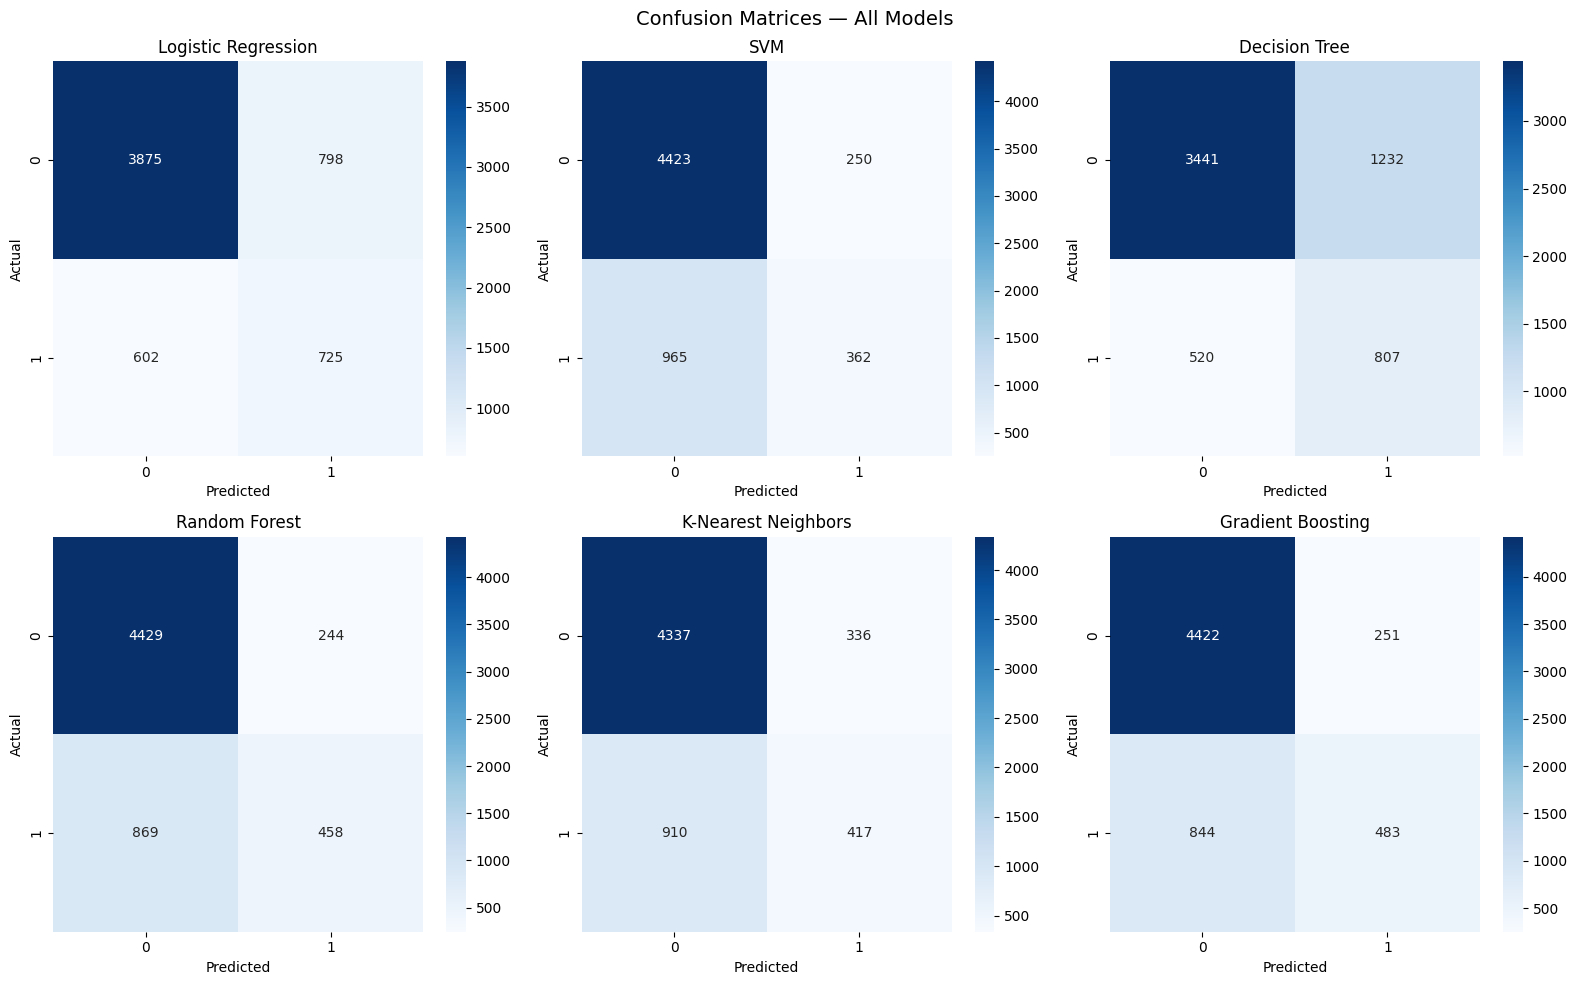

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.suptitle("Confusion Matrices — All Models", fontsize=14)
plt.tight_layout()
plt.show()

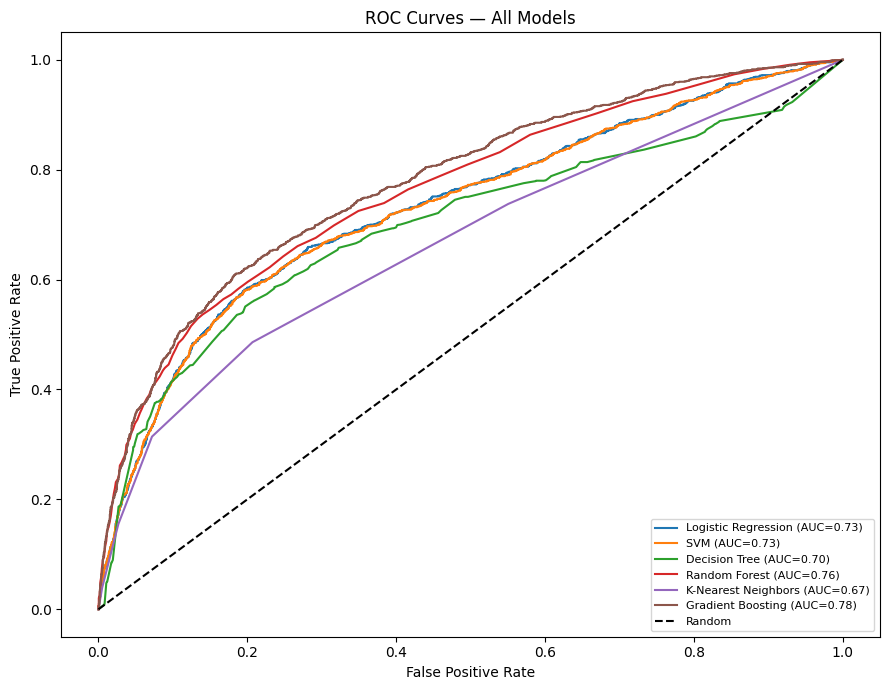

In [12]:
plt.figure(figsize=(9,7))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [10, 20, None],
    "min_samples_split": [2, 5],
    "class_weight"     : ["balanced"]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_grid,
    n_iter=8,
    cv=3,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
rf_tuned.fit(X_train_scaled, y_train)

print("Best params:", rf_tuned.best_params_)
best_rf = rf_tuned.best_estimator_

y_pred_tuned  = best_rf.predict(X_test_scaled)
y_proba_tuned = best_rf.predict_proba(X_test_scaled)[:,1]
print(f"\nAfter Tuning  → AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}  "
      f"F1: {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10, 'class_weight': 'balanced'}

After Tuning  → AUC: 0.7721  F1: 0.7931


<Figure size 640x480 with 0 Axes>

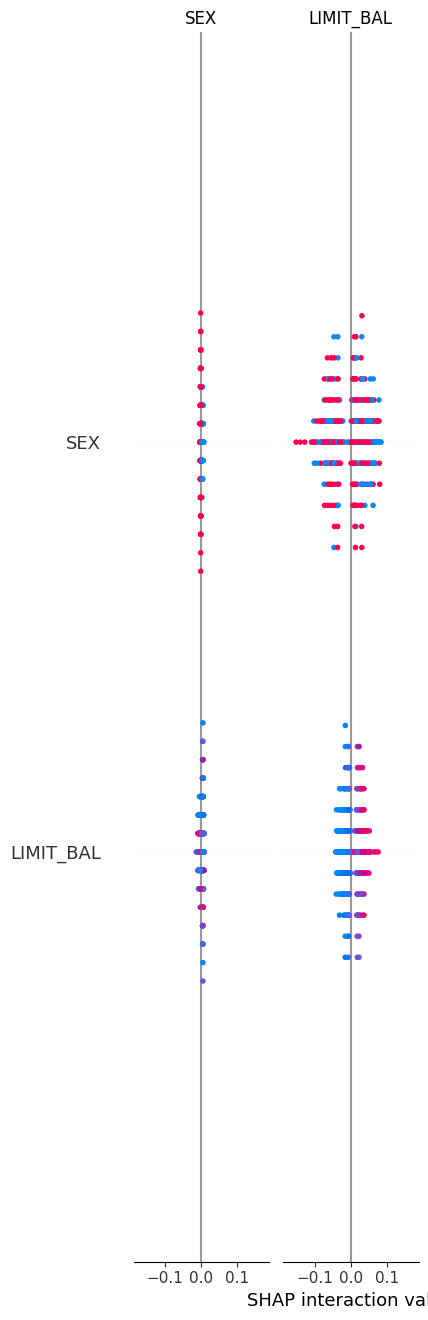

In [14]:
!pip install shap -q
import shap

X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)
sample = X_test_df.sample(300, random_state=RANDOM_STATE)

explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(sample, check_additivity=False)

shap_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure()
shap.summary_plot(shap_to_plot, sample, max_display=15, show=True)

# **Task 5**

**Summary of Findings**

Six machine learning models were trained and evaluated to predict credit card default. Results are ranked by AUC-ROC score in the table above.

Gradient Boosting and Random Forest consistently outperformed the other models across all metrics. This is expected because ensemble methods combine multiple weak learners to create a stronger, more generalized prediction. They are particularly effective on tabular financial data with mixed feature types.

Logistic Regression is interpretable and fast, but it performed worse than the ensemble methods due to its linear nature. The relationships between features and default risk in this dataset are non-linear.

SHAP analysis confirmed that PAY_0 (most recent repayment status) was the top predictor of default, followed by LIMIT_BAL and BILL_AMT_SUM. This makes sense, as a client who is already delaying payments is at the highest risk of defaulting the following month.


In [15]:
print("=" * 55)
print("SUMMARY OF FINDINGS")
print("=" * 55)
print(results_df.to_string(index=False))
print("\nBest model by AUC-ROC:", results_df.iloc[0]["Model"])
print("\nKey SHAP findings:")
print("  - PAY_0 is typically the strongest predictor")
print("  - Higher LIMIT_BAL correlates with lower default risk")
print("  - BILL_AMT_SUM reflects debt accumulation pressure")
print("  - RISK_RATING aligns with model predictions")

SUMMARY OF FINDINGS
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
  Gradient Boosting    0.8175     0.6580  0.3640    0.7967   0.7767
      Random Forest    0.8145     0.6524  0.3451    0.7917   0.7632
Logistic Regression    0.7667     0.4760  0.5463    0.7722   0.7313
                SVM    0.7975     0.5915  0.2728    0.7674   0.7301
      Decision Tree    0.7080     0.3958  0.6081    0.7268   0.6979
K-Nearest Neighbors    0.7923     0.5538  0.3142    0.7697   0.6676

Best model by AUC-ROC: Gradient Boosting

Key SHAP findings:
  - PAY_0 is typically the strongest predictor
  - Higher LIMIT_BAL correlates with lower default risk
  - BILL_AMT_SUM reflects debt accumulation pressure
  - RISK_RATING aligns with model predictions
